<a href="https://colab.research.google.com/github/UMB200/AI_ML_pytorch_projects/blob/main/10_Pytorch_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch, torchvision, os, zipfile, random, requests, sys, pathlib, time
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from timeit import default_timer as timer
import tqdm.auto as tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from typing import List, Dict, Tuple
import pandas as pd
import gradio as gr
import shutil
from IPython.display import IFrame
from torch.utils.data import random_split

model = torchvision.models.resnet50()

In [2]:
! lscpu | grep 'Model name'

Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz


### 1.0 After PyTorch 2.0

In [3]:
model = torchvision.models.resnet50()
compiled_modedl = torch.compile(model)

### 1.1 Globally set devices

In [4]:
import torch

# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the device with context manager (requires PyTorch 2.x+)
with torch.device(device):
    # All tensors created in this block will be on device
    layer = torch.nn.Linear(20, 30)
    print(f"Layer weights are on device: {layer.weight.device}")
    print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


In [5]:
# Set device globally
torch.set_default_device(device)

# All tensors or PyTorch objects created from here would be on the target device
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device: cuda:0


In [6]:
# Set device globally
torch.set_default_device("cpu")

# All tensors or PyTorch objects created from here would be on the target device
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device: {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cpu
Layer creating data on device: cpu


### 1.2 Get GPU Info

In [7]:
if torch.cuda.is_available():
  gpu_info = !nvidia-smi
  gpu_info = '\n'.join(gpu_info)
  if gpu_info.find("failed") >=0:
    print(f" No GPU is available")

  # Get GPU Name
  gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv
  gpu_name = gpu_name[1]
  GPU_NAME = gpu_name.replace(" ", " _")
  print(f" GPU name: {GPU_NAME}")

  # Get GPU Score
  GPU_SCORE = torch.cuda.get_device_capability()
  if GPU_SCORE >=(8, 0):
    print(f" GPU score: {GPU_SCORE}, Pytorch 2.x speed up is available")
  else:
    print(f" GPU score: {GPU_SCORE}, Pytorch 2.x speed up is not available")

 GPU name: Tesla _T4
 GPU score: (7, 5), Pytorch 2.x speed up is not available


## 2.0 Setting up the experiments
* Model: ResNet 50
* Data: CIFAR 10
* Epochs 5 single run and 3x5 multirun
* Batchs size: 128
* Image size: 224

### 2.1 Create model and transforms

In [8]:
resnet50_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
resnet50_transforms = resnet50_weights.transforms()
resnet50_model = torchvision.models.resnet50(weights=resnet50_weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


In [9]:
# Count the number of parameters in the model
total_params = sum(p.numel() for p in resnet50_model.parameters())
print(f"Total parameters of ResNet50 model: {total_params:,}")

Total parameters of ResNet50 model: 25,557,032


In [10]:
def create_resnet50_model(num_classes=10,):
  resnet50_weights = torchvision.models.ResNet50_Weights.DEFAULT
  resnet50_transforms = resnet50_weights.transforms()
  resnet50_model = torchvision.models.resnet50(weights=resnet50_weights)

  # Adjust the head layer
  resnet50_model.fc = torch.nn.Linear(in_features=2048,
                                      out_features=num_classes)
  return resnet50_model, resnet50_transforms

model, transforms = create_resnet50_model()
transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### 2.2 Speedups are most noticable when large portion of GPU is used

### 2.3 Checking the memory limits of GPU

If the total memory on the GPU available is above 16GB, let's use a batch size of 128 and an image size of 224 (both of these values can be increased on GPUs with more memory).

If the total memory on the GPU available is below 16GB, let's use a batch size of 32 and an image size of 64 (both of these values can be altered on GPUs with less memory).

In [11]:
!nvidia-smi

Wed Nov 26 14:55:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             27W /   70W |     136MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
total_free_memory, total_gpu_memory = torch.cuda.mem_get_info()
total_free_memory_gb = round(total_free_memory * 1e-9, 2)
total_gpu_memory_gb = round(total_gpu_memory * 1e-9, 2)
print(f"Total free memory: {total_free_memory_gb} GB")
print(f"Total gpu memory: {total_gpu_memory_gb} GB")

Total free memory: 15.68 GB
Total gpu memory: 15.83 GB


In [13]:
# Set batch size depending on GPU memory
BATCH_SIZE = 0
IMAGE_SIZE = 0

if total_free_memory_gb >= 16:
  BATCH_SIZE = 128
  IMAGE_SIZE = 224
else:
  BATCH_SIZE = 32
  IMAGE_SIZE = 128

print(f"GPU available memory is: {total_free_memory_gb} GB; \nUsing batch size: {BATCH_SIZE}; \nImage size: {IMAGE_SIZE}; \nTransforms {transforms}")

GPU available memory is: 15.68 GB; 
Using batch size: 32; 
Image size: 128; 
Transforms ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [14]:
transforms.crop_size = 224
transforms.resize_size = 224
print(f"Updated data transforms: {transforms}")

Updated data transforms: ImageClassification(
    crop_size=224
    resize_size=224
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 2.4 More potential speedups with TF32

In [15]:
print(f"status of TF32 {torch.backends.cuda.matmul.allow_tf32 }")

status of TF32 False


/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()


In [16]:
if GPU_SCORE >= (8, ):
  print(f"Using GPU with score {GPU_SCORE} enabling TensorFlow32 (TF32) comopting (faster on new GPU)")
  torch.backends.cuda.matmul.allow_tf32 = True
else:
  print(f"Using GPU with score {GPU_SCORE}  TensorFlow32 (TF32) is not available because GPU_SCORE is less than (8,0)")
  torch.backends.cuda.matmul.allow_tf32 = False

Using GPU with score (7, 5)  TensorFlow32 (TF32) is not available because GPU_SCORE is less than (8,0)


### 2.5 Preparing CIFAR10 datasets

In [17]:
# Create datasets
train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=transforms)

test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transforms)

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


In [18]:
# Check the length of each dataset
train_length = len(train_dataset)
test_length = len(test_dataset)
print(f"Length of train dataset: {train_length:,} images")
print(f"Length of test dataset: {test_length:,} images")

Length of train dataset: 50,000 images
Length of test dataset: 10,000 images


### 2.6 Create DataLoaders

In [19]:
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# print the length of batches in each dataloader
print(f"Train dataloader number of batches: {len(train_dataloader)} of batch size: {BATCH_SIZE}")
print(f"Test dataloader number of batches: {len(test_dataloader)} of batch size: {BATCH_SIZE}")
print(f"Number of workers: {NUM_WORKERS}")


Train dataloader number of batches: 1563 of batch size: 32
Test dataloader number of batches: 313 of batch size: 32
Number of workers: 2



### 2.7 Create training and testing loops

In [20]:
from modulefinder import test
# Create a dictionary to store training and testing times
training_loop_dict = {}
testing_loop_dict = {}

def train_step_loop(model: torch.nn.Module,
                    epoch: int,
                    data_loader: torch.utils.data.DataLoader,
                    loss_fn: torch.nn.Module,
                    optimizer: torch.optim.Optimizer,
                    device: torch.device, disable_progress_bar: bool = False, ) -> Tuple[float, float]:

  model.train()
  train_loss, train_acc = 0, 0
  progress_bar = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Training epoch {epoch}", disable=disable_progress_bar)

  for batch, (X, y) in progress_bar:
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    #Update progress bar
    progress_bar.set_postfix({"train_loss": train_loss/(batch+1),
                             "train_acc": train_acc/(batch+1)})


  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  return train_loss, train_acc

def test_step_loop(model: torch.nn.Module,
                    data_loader: torch.utils.data.DataLoader,
                   epoch: int,
                   loss_fn: torch.nn.Module,
                   device: torch.device,
                  disable_progress_bar: bool = False,) -> Tuple[float, float]:
  model.eval()
  test_loss, test_acc = 0, 0

  progress_bar = tqdm(enumerate(data_loader), total=len(data_loader), desc=f"Testing epoch {epoch}", disable=disable_progress_bar)


  with torch.no_grad():
    for batch, (X, y) in progress_bar:
      X, y = X.to(device), y.to(device)
      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      # Update progress bar
      progress_bar.set_postfix({
          "test_loss": test_loss/(batch+1),
          "test_acc": test_acc/(batch+1)
      })

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)
  test_loss /= len(data_loader)
  test_acc /= len(data_loader)

  return test_loss, test_acc

def train(model: torch.nn.Module,
               train_dataloader: torch.utils.data.DataLoader,
               test_dataloader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module,
               epochs: int,
               device: torch.device,
               scheduler: torch.optim.lr_scheduler._LRScheduler = None,
          disable_progress_bar: bool = False,)-> Dict[str, List]:

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": [],
             "train_epoch_time": [],
             "test_epoch_time": []}
  for epoch in tqdm(range(epochs), disable=disable_progress_bar):

    # Train
    train_epoch_start_time = time.time()
    train_loss, train_acc = train_step_loop(model=model,
                                            data_loader=train_dataloader,
                                            loss_fn=loss_fn,
                                            epoch=epoch,
                                            optimizer=optimizer,
                                            device=device,
                                            disable_progress_bar=disable_progress_bar)
    train_epoch_end_time = time.time()
    train_epoch_time = train_epoch_end_time - train_epoch_start_time

    # Test
    test_epoch_start_time = time.time()
    test_loss, test_acc = test_step_loop(model=model,
                                        data_loader=test_dataloader,
                                        loss_fn=loss_fn,
                                          epoch=epoch,
                                        device=device,
                                         disable_progress_bar=disable_progress_bar)
    test_epoch_end_time = time.time()
    test_epoch_time = test_epoch_end_time - test_epoch_start_time

    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f} | "
          f"train_epoch_time: {train_epoch_time:.4f} |"
          f"test_epoch_time: {test_epoch_time:.4f}")
    if scheduler is not None:
      # If using ReduceLROnPlateau, use validation loss; else, just step()
      if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(test_loss)
      else:
        scheduler.step()
    get_tensor_val = lambda x: x.item() if isinstance(x, torch.Tensor) else x
    results["train_loss"].append(get_tensor_val(train_loss))
    results["train_acc"].append(get_tensor_val(train_acc))
    results["test_loss"].append(get_tensor_val(test_loss))
    results["test_acc"].append(get_tensor_val(test_acc))
    results["train_epoch_time"].append(train_epoch_time)
    results["test_epoch_time"].append(test_epoch_time)
  return results

## 3.0 Time models across single run

In [21]:
NUM_EPOCH = 5
LEARNING_RATE = 0.03

### 3.1 Experiment 1 - Single Run, no compile

In [22]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
model.to(device)

single_run_output_no_compile = train(
    model=model,
  train_dataloader=train_dataloader,
  test_dataloader=test_dataloader,
    loss_fn=loss_fn,
  optimizer=optimizer,
  epochs=NUM_EPOCH,
  device=device
)

  0%|          | 0/8 [00:00<?, ?it/s]

Training epoch 0:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing epoch 0:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.0814 | train_acc: 0.2403 | test_loss: 1.7193 | test_acc: 0.3336 | train_epoch_time: 497.2423 |test_epoch_time: 34.1513


Training epoch 1:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Testing epoch 6:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 7 | train_loss: 0.6934 | train_acc: 0.7598 | test_loss: 0.7238 | test_acc: 0.7488 | train_epoch_time: 494.9741 |test_epoch_time: 34.9188


Training epoch 7:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing epoch 7:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 8 | train_loss: 0.6233 | train_acc: 0.7850 | test_loss: 0.6546 | test_acc: 0.7761 | train_epoch_time: 494.1969 |test_epoch_time: 34.7005


### 3.2 Experiment 2 - Single run, with compile

In [23]:
model_2, _ = create_resnet50_model()
model_2.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=LEARNING_RATE)

# Compile model and time how long it takes
compile_start_time = time.time()
compiled_model_2 = torch.compile(model_2)
compile_end_time = time.time()
compile_time = compile_end_time - compile_start_time
print(f"Model_2 compilation time: {compile_time:.4f} seconds")

# Train the compiled model
single_run_output_with_compile = train(
    model=compiled_model_2,
  train_dataloader=train_dataloader,
  test_dataloader=test_dataloader,
    loss_fn=loss_fn,
  optimizer=optimizer,
  epochs=NUM_EPOCH,
  device=device
)

Model_2 compilation time: 0.0023 seconds


  0%|          | 0/8 [00:00<?, ?it/s]

Training epoch 0:   0%|          | 0/1563 [00:00<?, ?it/s]

W1126 16:07:20.487000 191 torch/_inductor/utils.py:1558] [0/0] Not enough SMs to use max_autotune_gemm mode


Testing epoch 0:   0%|          | 0/313 [00:00<?, ?it/s]

...

Testing epoch 6:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 7 | train_loss: 0.6949 | train_acc: 0.7566 | test_loss: 0.8173 | test_acc: 0.7241 | train_epoch_time: 454.6058 |test_epoch_time: 30.7076


Training epoch 7:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing epoch 7:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch: 8 | train_loss: 0.6233 | train_acc: 0.7821 | test_loss: 0.7751 | test_acc: 0.7406 | train_epoch_time: 453.5263 |test_epoch_time: 31.1676


### 3.3 Compare the results of experiment 1 and 2

In [24]:
# Adding experiment outputs to dataframe for analysis
single_run_output_no_compile_df = pd.DataFrame(single_run_output_no_compile)
single_run_output_with_compile_df = pd.DataFrame(single_run_output_with_compile)

single_run_output_no_compile_df["experiment"] = "no_compile"
single_run_output_with_compile_df["experiment"] = "with_compile"

# Concatenate the dataframes
results_df = pd.concat([single_run_output_no_compile_df, single_run_output_with_compile_df])
results_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time,experiment
0,2.081391,0.240343,1.719344,0.333566,497.242306,34.151345,no_compile
1,1.504950,0.441799,1.306800,0.524960,512.144440,40.159734,no_compile
2,1.170230,0.579335,1.709427,0.466354,506.349524,34.949566,no_compile
3,1.013289,0.641275,1.021817,0.637480,507.086546,33.940017,no_compile
4,0.875715,0.694498,1.085026,0.641773,507.243733,33.910452,no_compile
5,0.774508,0.729906,0.893497,0.694688,496.563654,34.651913,no_compile
6,0.693415,0.759817,0.723828,0.748802,494.974104,34.918811,no_compile
7,0.623345,0.784989,0.654598,0.776058,494.196879,34.700510,no_compile
0,2.156182,0.252139,1.701891,0.373902,604.996388,50.793383,with_compile
1,1.487854,0.449696,1.350697,0.504792,461.932367,30.954994,with_compile


In [25]:
# Variables to save the results to file
DATASET_NAME = "CIFAR10"
MODEL_NAME = "ResNet50"

# Show the mean of epoch times
def show_mean_epoch_times(
    non_compiled_results: pd.DataFrame,
    compiled_results: pd.DataFrame,
    multi_runs: bool=False,
    number_runs: int=0,
    save: bool=False,
    save_path: str="",
    dataset_name: str=DATASET_NAME,
    model_name: str=MODEL_NAME,
    num_epochs: int=NUM_EPOCH,
    batch_size: int=BATCH_SIZE,
    image_size: int=IMAGE_SIZE) -> plt.figure:

  # Get the mean epoch time from non-compiled models
  mean_noncompiled_train_epoch_time = non_compiled_results.train_epoch_time.mean()
  mean_noncompiled_test_epoch_time = non_compiled_results.test_epoch_time.mean()
  mean_noncompiled_results = [
      mean_noncompiled_train_epoch_time,
      mean_noncompiled_test_epoch_time]

  # Get the mean epoch times from compiled models
  mean_compile_train_epoch_time = compiled_results.train_epoch_time.mean()
  mean_compile_test_epoch_time = compiled_results.test_epoch_time.mean()
  mean_compile_results = [
      mean_compile_train_epoch_time,
      mean_compile_test_epoch_time]

  # Calculate the percentage difference between the mean compiled and non-compile train epoch times
  train_epoch_time_difference = mean_compile_train_epoch_time - mean_noncompiled_train_epoch_time
  train_epoch_time_percentage_difference = (train_epoch_time_difference / mean_noncompiled_train_epoch_time) * 100

  # Calculate the persentage difference between mean of compile and nomcompile test epoch times
  test_epoch_time_difference = mean_compile_test_epoch_time - mean_noncompiled_test_epoch_time
  test_epoch_time_percentage_difference = (test_epoch_time_difference / mean_noncompiled_test_epoch_time) * 100

  # Print the persentages
  print(f"Train epoch time percentage difference: {train_epoch_time_percentage_difference:.2f}%")
  print(f"Test epoch time percentage difference: {test_epoch_time_percentage_difference:.2f}%")

  # Plot the mean and test epoch times for both options
  plt.figure(figsize=(10, 6))
  width = 0.3
  x_indices = np.arange(len(mean_compile_results))

  plt.bar(
      x=x_indices,
      height=mean_noncompiled_results,
      width=width,
      label="Non-compiled results")
  plt.bar(x=x_indices + width,
          height=mean_compile_results,
          width=width,
          label="Compiled results")
  plt.xticks(x_indices + width / 2, ["Train epoch time", "Test epoch time"])
  plt.xlabel("Epoch time")

  plt.ylabel("Mean epoch time in seconds")

  # Change the title based on function parameters
  plt.suptitle(f"{'Multi-run' if multi_runs else 'Single'}-run results")
  plt.title(f"GPU: {GPU_NAME} | Epochs: {num_epochs} ({number_runs} runs) | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size {batch_size}")
  plt.legend();

  # Save the image
  if save:
    assert save_path !="", "please specify a save path"
    plt.savefig(save_path)
    print(f"Image saved to {save_path}")


Saving image to pytorch2_results/plots/single_run_Tesla _T4_ResNet50_CIFAR10_128_train_epoch_time.png
Train epoch time percentage difference: -5.22%
Test epoch time percentage difference: -5.44%
Image saved to pytorch2_results/plots/single_run_Tesla _T4_ResNet50_CIFAR10_128_train_epoch_time.png


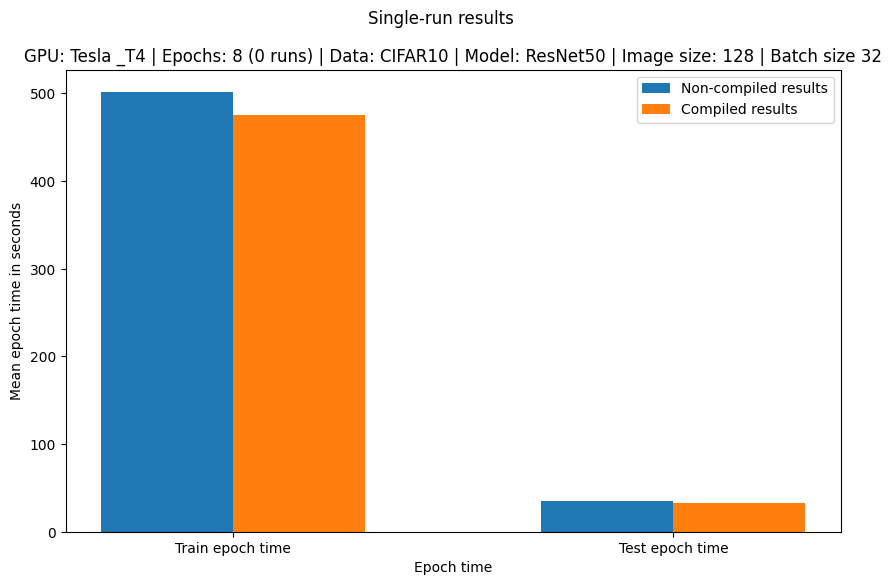

In [26]:
# Directory for saving the figures of bars
dir_pytorch2_results = "pytorch2_results/plots/"
os.makedirs(dir_pytorch2_results, exist_ok=True)
dir_pytorch2_single_run_results = f"{dir_pytorch2_results}single_run_results"

run_details = f"{GPU_NAME}_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}"

save_path_multi_run = f"{dir_pytorch2_results}single_run_{run_details}_train_epoch_time.png"
print(f"Saving image to {save_path_multi_run}")

show_mean_epoch_times(
    non_compiled_results=single_run_output_no_compile_df,
    compiled_results=single_run_output_with_compile_df,
    multi_runs=False,
    save_path=save_path_multi_run,
    save=True)

### 3.4 Save single run results to file with GPU details

In [27]:
# Save single run results
dir_pytorch2_results = "pytorch2_results/"
dir_pytorch2_single_run_results = f"{dir_pytorch2_results}single_run_results"
os.makedirs(dir_pytorch2_single_run_results, exist_ok=True)

# Filenames for each of the dataframes
filename_no_compile = f"single_run_noncompiled_{run_details}.csv"
filename_with_compile = f"single_run_compiled_{run_details}.csv"

# Filepaths for saved results
filepath_no_compile = f"{dir_pytorch2_single_run_results}/{filename_no_compile}"
filepath_with_compile = f"{dir_pytorch2_single_run_results}/{filename_with_compile}"

# Print saved info
print(f"Saving non-compiled experiment 1 results to: {filepath_no_compile}")
print(f"Saving compiled experiment 2 results to: {filepath_with_compile}")

# Save the results
single_run_output_no_compile_df.to_csv(filepath_no_compile, index=False)
single_run_output_with_compile_df.to_csv(filepath_with_compile, index=False)


Saving non-compiled experiment 1 results to: pytorch2_results/single_run_results/single_run_noncompiled_Tesla _T4_ResNet50_CIFAR10_128.csv
Saving compiled experiment 2 results to: pytorch2_results/single_run_results/single_run_compiled_Tesla _T4_ResNet50_CIFAR10_128.csv


## 4.0 Time models across multiple runs

In [28]:
def create_train_noncompiled_model (
    epochs=NUM_EPOCH,
    learning_rate=LEARNING_RATE,
    disable_progess_bar=False):

  model, _ = create_resnet50_model()
  model.to(device)

  loss_fun = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

  output = train(
      model=model,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      loss_fn=loss_fun,
      optimizer=optimizer,
      epochs=epochs,
      device=device,
      disable_progress_bar=disable_progess_bar)
  return output

def create_compiled_model():
  model, _ = create_resnet50_model()
  model.to(device)

  compile_start_time = time.time()
  compiled_model = torch.compile(model)
  compile_end_time = time.time()
  compile_time = compile_end_time - compile_start_time
  print(f"Model compilation time: {compile_time:.4f} seconds")

  return compiled_model


def train_compiled_model(
    model = compiled_model_2,
    epochs=NUM_EPOCH,
    learning_rate=LEARNING_RATE,
    disable_progess_bar=False):

  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
  output = train(
      model=model,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      epochs=epochs,
      device=device,
      disable_progress_bar=disable_progess_bar)
  return output

### 4.1 Experiment 3 - Multiple runs, noncompile type of models

In [29]:
NUM_EPOCH = 5
NUM_RUN = 3

list_for_noncompiled_multirun_results = []

for i in tqdm(range(NUM_RUN)):
  print(f"Run {i+1} of {NUM_RUN} for noncompiled model")
  output = create_train_noncompiled_model(
      epochs=NUM_EPOCH,
      disable_progess_bar=True)
  list_for_noncompiled_multirun_results.append(output)

  0%|          | 0/3 [00:00<?, ?it/s]

Run 1 of 3 for noncompiled model
Epoch: 1 | train_loss: 2.1688 | train_acc: 0.1881 | test_loss: 2.1058 | test_acc: 0.2470 | train_epoch_time: 488.5098 |test_epoch_time: 33.6731
Epoch: 2 | train_loss: 1.6542 | train_acc: 0.3676 | test_loss: 1.5007 | test_acc: 0.4551 | train_epoch_time: 491.7718 |test_epoch_time: 33.7262
Epoch: 3 | train_loss: 1.3564 | train_acc: 0.5005 | test_loss: 1.2295 | test_acc: 0.5439 | train_epoch_time: 491.0756 |test_epoch_time: 33.4472
Epoch: 4 | train_loss: 1.1088 | train_acc: 0.6006 | test_loss: 1.1425 | test_acc: 0.5787 | train_epoch_time: 488.6808 |test_epoch_time: 32.8422
Epoch: 5 | train_loss: 0.9491 | train_acc: 0.6623 | test_loss: 0.9560 | test_acc: 0.6538 | train_epoch_time: 486.8035 |test_epoch_time: 32.7747
Run 2 of 3 for noncompiled model
Epoch: 1 | train_loss: 2.1054 | train_acc: 0.2350 | test_loss: 1.5924 | test_acc: 0.4085 | train_epoch_time: 493.8306 |test_epoch_time: 33.1261
Epoch: 2 | train_loss: 1.4306 | train_acc: 0.4733 | test_loss: 1.9491 

In [30]:
# Create dataframe for the results of multiple runs above
noncompile_results_df = []

# Loop through the list of results and create a dataframe for each one
for r in list_for_noncompiled_multirun_results:
  r_df = pd.DataFrame(r)
  noncompile_results_df.append(r_df)
noncompiled_results_multiruns_df = pd.concat(noncompile_results_df)

# Average accross multiruns
noncompiled_results_multiruns_df = noncompiled_results_multiruns_df.groupby(noncompiled_results_multiruns_df.index).mean()
noncompiled_results_multiruns_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,2.200193,0.206261,1.897038,0.304080,490.177074,33.215858
1,1.572900,0.407083,1.638048,0.437267,492.546604,33.295244
2,1.306040,0.520873,3.325009,0.524028,491.514022,33.257385
3,1.119030,0.595749,1.099989,0.604766,489.052155,32.803870
4,0.980320,0.650379,1.011609,0.641673,487.162920,32.997387


### 4.2 Experiment 4 - Multiple runs, with compile

In [ ]:
compiled_model_2 = create_compiled_model()
list_complied_results_multirun = []

for i in tqdm(range(NUM_RUN)):
  print(f"Run {i+1} of {NUM_RUN} for compiled model")
  output = train_compiled_model(model=compiled_model_2, epochs=NUM_EPOCH, disable_progess_bar=True)
  list_complied_results_multirun.append(output)

Model compilation time: 0.0025 seconds


  0%|          | 0/3 [00:00<?, ?it/s]

Run 1 of 3 for compiled model
Epoch: 1 | train_loss: 2.1353 | train_acc: 0.2349 | test_loss: 1.6718 | test_acc: 0.3604 | train_epoch_time: 452.5931 |test_epoch_time: 30.1585
Epoch: 2 | train_loss: 1.5661 | train_acc: 0.4103 | test_loss: 2.8212 | test_acc: 0.2909 | train_epoch_time: 461.1612 |test_epoch_time: 30.2966
Epoch: 3 | train_loss: 1.3329 | train_acc: 0.5110 | test_loss: 1.2044 | test_acc: 0.5661 | train_epoch_time: 463.2365 |test_epoch_time: 33.6196


In [ ]:
compiled_results_df = []

for r in list_complied_results_multirun:
  r_df = pd.DataFrame(r)
  compiled_results_df.append(r_df)
compile_results_multiruns_df = pd.concat(compiled_results_df)

compile_results_multiruns_df = compile_results_multiruns_df.groupby(compile_results_multiruns_df.index).mean()
compile_results_multiruns_df

### 4.3 Compare results of experiment 3 and 4

In [ ]:
os.makedirs(dir_pytorch2_results, exist_ok=True)
save_path_multi_run_compiled = f"{dir_pytorch2_results}multirun_{run_details}_train_epoch_time.png"
print(f"Saving image to {save_path_multi_run_compiled}")

show_mean_epoch_times(
    non_compiled_results=noncompiled_results_multiruns_df,
    compiled_results=compile_results_multiruns_df,
    multi_runs=True,
    save_path=save_path_multi_run_compiled,
    save=True)

### 4.4 Save multi run results to file with GPU details

In [ ]:
dir_pytorch2_multirun_results = f"{dir_pytorch2_results}/multi_run_results"
os.makedirs(dir_pytorch2_multirun_results, exist_ok=True)

# Filenames for each dataframe
filename_multirun_noncompile = f"multirun_noncompiled_resulst_{run_details}.csv"
filename_multirun_compile = f"multirun_compiled_results_{run_details}.csv"

# Filepaths for saved results
filepath_multirun_noncompile = f"{dir_pytorch2_multirun_results}/{filename_multirun_noncompile}"
filepath_multirun_compile = f"{dir_pytorch2_multirun_results}/{filename_multirun_compile}"
print(f"Saving experiment 3 for non-compiled results to {filepath_multirun_noncompile}")
print(f"Saving experiment 4 for compiled results to {filepath_multirun_compile}")

# Save the results
noncompiled_results_multiruns_df.to_csv(filepath_multirun_noncompile, index=False)
compile_results_multiruns_df.to_csv(filepath_multirun_compile, index=False)